# Assignment 4 - Portugal
# Visualizations

Requires outputs from `EAnalysis.ipynb` and `PyPSA.ipynb`.

Outputs covered:
1. Total system cost split by technology
2. Capacity built per technology
3. Electricity mix
4. CO₂ shadow price
5. Price duration curves
6. Average electricity prices per region
7. Rate of curtailment
8. Storage filling levels
9. System operation (example week)
10. Sensitivity analysis

In [11]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, geopandas as gpd
import matplotlib.pyplot as plt
import pypsa

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11})

COLORS = {
    'solar':    '#f4a261',  # orange
    'onwind':   '#457b9d',  # mid blue
    'offwind':  '#1d3557',  # dark navy
    'hydro':    '#3a86ff',  # water blue
    'gas':      '#a0522d',  # brown
    'coal':     '#343a40',  # dark grey
    'biomass':  '#2d6a4f',  # forest green
    'waste':    '#e9c46a',  # sand yellow
    'battery':  '#e76f51',  # coral red
    'H2':       '#2a9d8f',  # teal
    'AC':       '#6c757d',  # grey
}

## Load Data

In [12]:
n_free = pypsa.Network('network_free.nc')
n_zero = pypsa.Network('network_zero.nc')
regions = gpd.read_file('regions.gpkg').set_index('nuts2')
regions['representative_point'] = regions.geometry.representative_point()
df_sens = pd.read_csv('sensitivity_results.csv', index_col=0)
print('n_free generators:', len(n_free.generators))
print('n_zero generators:', len(n_zero.generators))
df_sens

INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, links, loads, storage_units, sub_networks
INFO:pypsa.network.io:New version 1.2.4 available! (Current: 1.1.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, global_constraints, links, loads, storage_units, sub_networks


n_free generators: 37
n_zero generators: 37


,total_cost_bn_eur,solar_GW,onwind_GW,offwind_GW,gas_GW,battery_GW,H2_GW,transmission_GW
solar_cost_pct,,,,,,,,
100%,5.616021,26.112957,2.074086,3.305553,3.829,9.051705,2.037193,0.852668
75%,5.155605,30.487714,1.945878,2.528274,3.829,10.061717,1.767310,1.088562
50%,4.605447,37.886109,1.894372,1.890915,3.829,10.409008,1.531433,1.256095
25%,3.926765,48.258153,1.930631,1.794849,3.829,10.639725,1.247114,1.305012
0%,2.819549,87.632978,2.063425,1.460252,3.829,10.885048,0.889015,1.250026


---
## Fig 1: Total system cost split by technology

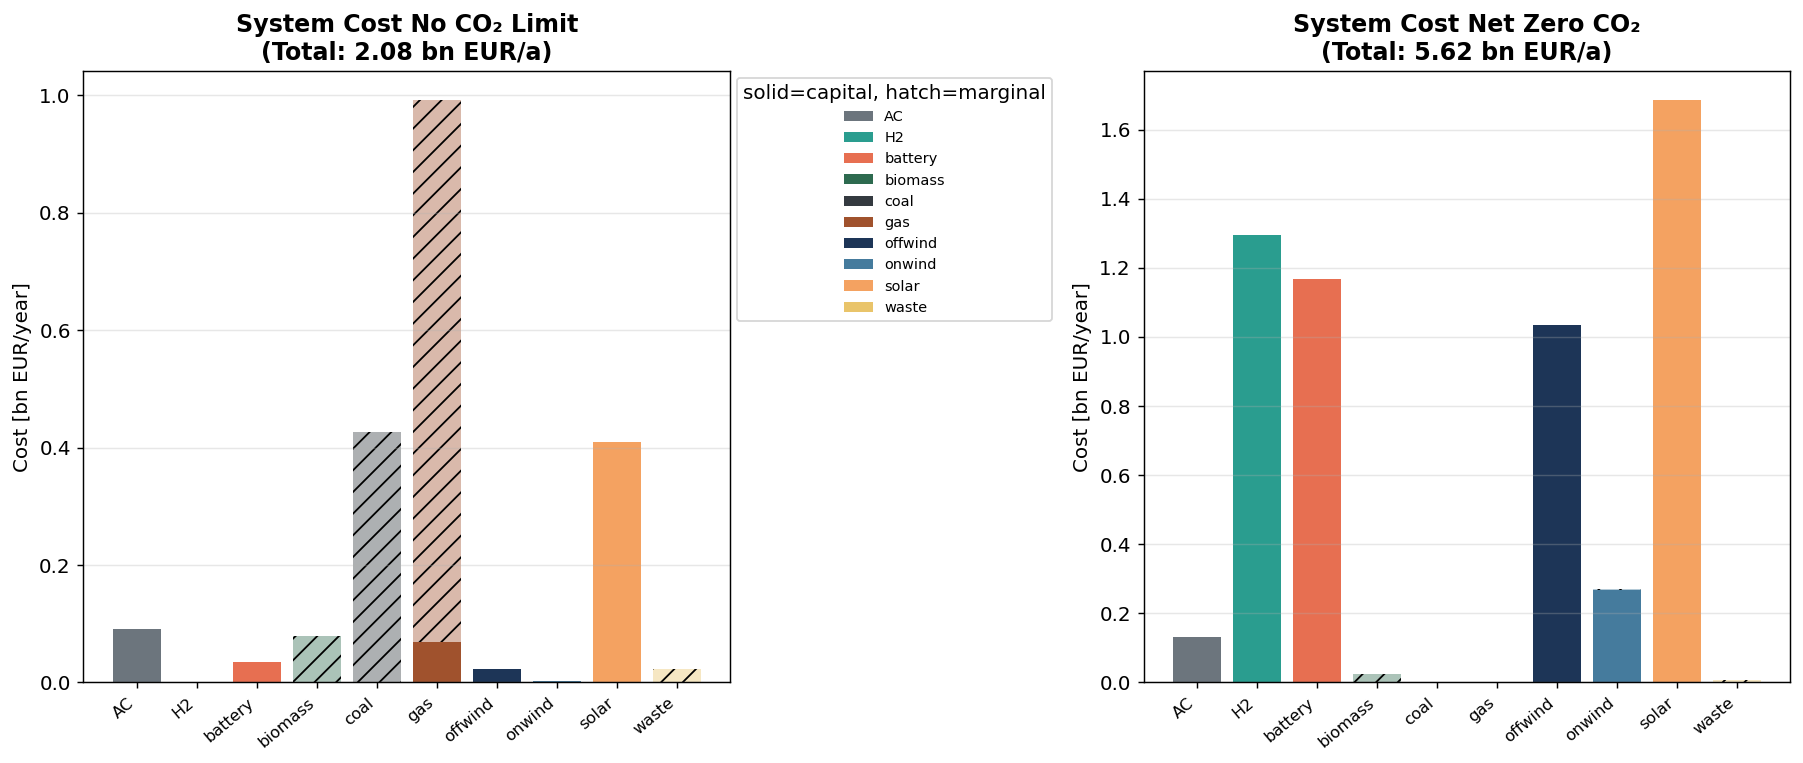

In [13]:
def cost_by_carrier(net):
    rows = []
    for name, g in net.generators.iterrows():
        dispatch = net.generators_t.p[name].multiply(net.snapshot_weightings.generators).sum()  # [MWh/a]
        rows.append({'carrier': g.carrier,
                     'capital':  g.capital_cost * g.p_nom_opt,      # [EUR/a]
                     'marginal': g.marginal_cost * dispatch})       # [EUR/a]
    for name, s in net.storage_units.iterrows():
        rows.append({'carrier': s.carrier,
                     'capital':  s.capital_cost * s.p_nom_opt, 'marginal': 0})  # [EUR/a]
    for name, lk in net.links.iterrows():
        rows.append({'carrier': 'AC', 'capital': lk.capital_cost * lk.p_nom_opt, 'marginal': 0})  # [EUR/a]
    df = pd.DataFrame(rows).groupby('carrier')[['capital', 'marginal']].sum() / 1e9  # [bn EUR/a]
    return df[df.sum(axis=1) > 0.001]

cost_free = cost_by_carrier(n_free)   # [bn EUR/a]
cost_zero = cost_by_carrier(n_zero)   # [bn EUR/a]
all_c = sorted(set(cost_free.index) | set(cost_zero.index))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, df, title in [(axes[0], cost_free, 'No CO₂ Limit'), (axes[1], cost_zero, 'Net Zero CO₂')]:
    df = df.reindex(all_c, fill_value=0)
    for i, c in enumerate(all_c):
        color = COLORS.get(c, '#adb5bd')
        ax.bar(i, df.at[c, 'capital'],  color=color, label=c if ax is axes[0] else '_')
        ax.bar(i, df.at[c, 'marginal'], bottom=df.at[c, 'capital'], color=color, alpha=0.4, hatch='//')
    ax.set_xticks(range(len(all_c))); ax.set_xticklabels(all_c, rotation=40, ha='right', fontsize=9)
    ax.set_ylabel('Cost [bn EUR/year]')
    ax.set_title(f'System Cost {title}\n(Total: {df.sum().sum():.2f} bn EUR/a)', fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3)
axes[0].legend(bbox_to_anchor=(1, 1), fontsize=8, title='solid=capital, hatch=marginal')
plt.tight_layout()
plt.savefig('fig1_system_cost.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
load = n_zero.loads_t.p_set.mul(n_zero.snapshot_weightings.generators, axis=0).sum().sum() / 1e6  # TWh
print(f"Durchschnittskosten Referenz: {n_free.objective/1e6/load:.1f} EUR/MWh")
print(f"Durchschnittskosten Net Zero: {n_zero.objective/1e6/load:.1f} EUR/MWh")

Durchschnittskosten Referenz: 37.2 EUR/MWh
Durchschnittskosten Net Zero: 100.5 EUR/MWh


Referenz   objective:   2.08   Summe Plot:   2.08 bn EUR/a
Net Zero   objective:   5.62   Summe Plot:   5.62 bn EUR/a


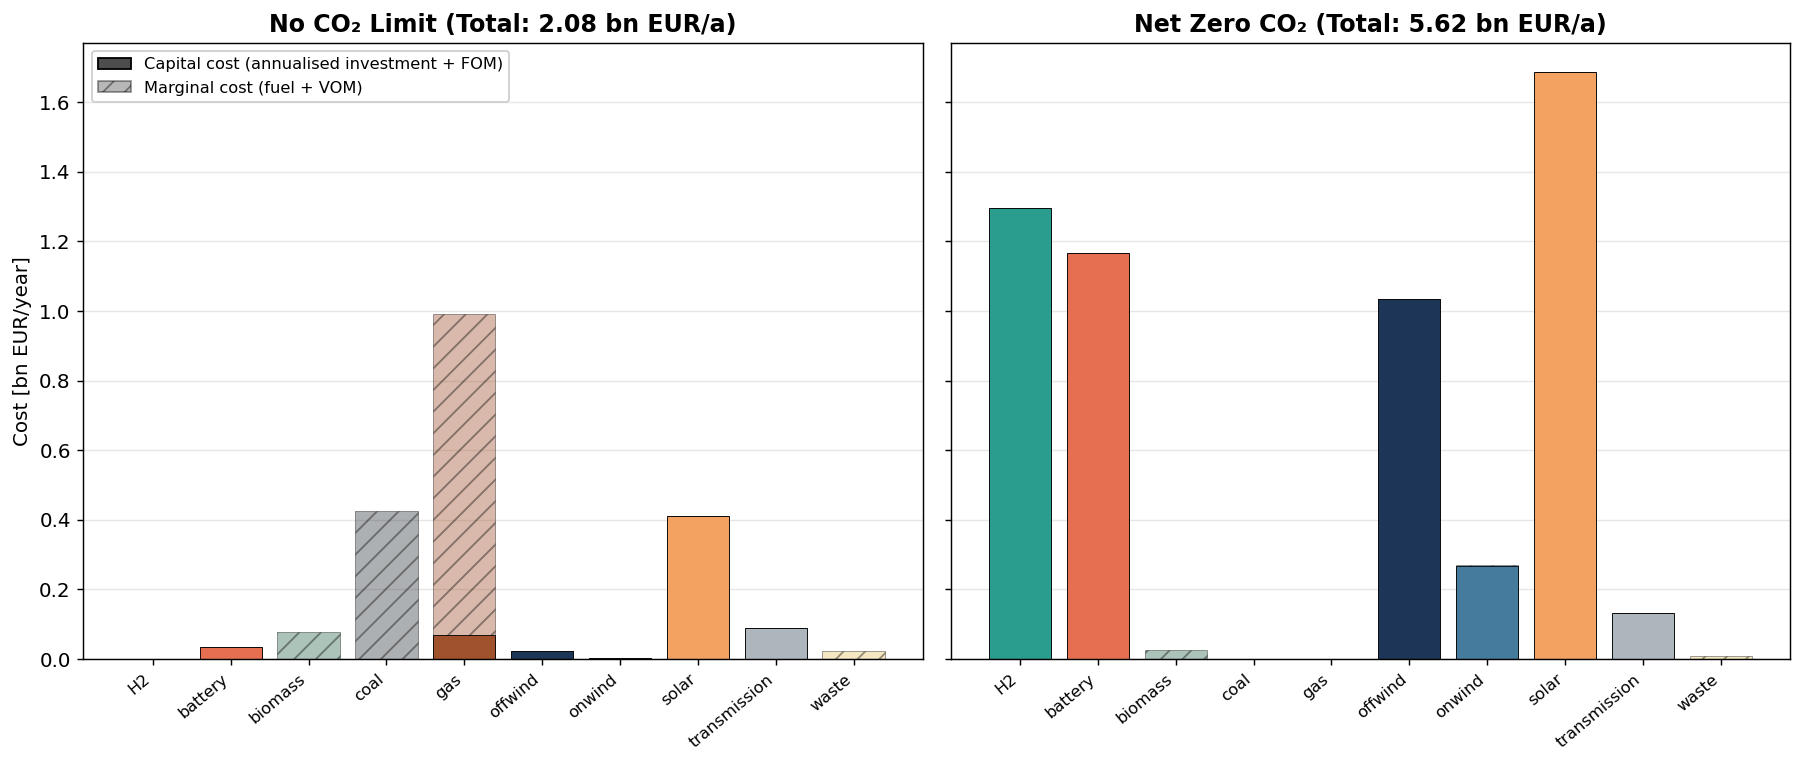

In [15]:
from matplotlib.patches import Patch

def cost_by_carrier(net, include_existing_capex=False):
    """
    Systemkosten je Carrier [bn EUR/a].

    include_existing_capex=False  -> nur Kapitalkosten für NEU gebaute Anlagen
                                     (p_nom_extendable=True). Entspricht dem, was
                                     PyPSA in der Zielfunktion minimiert.
    include_existing_capex=True   -> Vollkosten inkl. Bestandsanlagen (nur zur Info,
                                     weicht dann vom objective ab).
    """
    rows = []

    for name, g in net.generators.iterrows():
        dispatch = net.generators_t.p[name].multiply(
            net.snapshot_weightings.generators).sum()               # [MWh/a]
        if g.p_nom_extendable or include_existing_capex:
            capex = g.capital_cost * g.p_nom_opt                    # [EUR/a]
        else:
            capex = 0.0                                             # Bestand: versunken
        rows.append({'carrier': g.carrier,
                     'capital':  capex,
                     'marginal': g.marginal_cost * dispatch})

    for name, s in net.storage_units.iterrows():
        rows.append({'carrier': s.carrier,
                     'capital':  s.capital_cost * s.p_nom_opt,
                     'marginal': 0.0})

    for name, lk in net.links.iterrows():
        rows.append({'carrier': 'transmission',
                     'capital':  lk.capital_cost * lk.p_nom_opt,
                     'marginal': 0.0})

    df = pd.DataFrame(rows).groupby('carrier')[['capital', 'marginal']].sum() / 1e9
    return df[df.sum(axis=1) > 0.001]


cost_free = cost_by_carrier(n_free)
cost_zero = cost_by_carrier(n_zero)

# --- Konsistenz-Check gegen die Zielfunktion ---------------------------------
for label, net, df in [('Referenz', n_free, cost_free), ('Net Zero', n_zero, cost_zero)]:
    print(f"{label:9s}  objective: {net.objective/1e9:6.2f}   "
          f"Summe Plot: {df.sum().sum():6.2f} bn EUR/a")

# --- Plot --------------------------------------------------------------------
all_c = sorted(set(cost_free.index) | set(cost_zero.index))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

for ax, df, title in [(axes[0], cost_free, 'No CO₂ Limit'),
                      (axes[1], cost_zero, 'Net Zero CO₂')]:
    df = df.reindex(all_c, fill_value=0)
    for i, c in enumerate(all_c):
        color = COLORS.get(c, '#adb5bd')
        ax.bar(i, df.at[c, 'capital'], color=color,
               edgecolor='black', linewidth=0.5)
        ax.bar(i, df.at[c, 'marginal'], bottom=df.at[c, 'capital'],
               color=color, alpha=0.4, hatch='//',
               edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(all_c)))
    ax.set_xticklabels(all_c, rotation=40, ha='right', fontsize=9)
    ax.set_title(f'{title} (Total: {df.sum().sum():.2f} bn EUR/a)',
                 fontweight='bold')
    ax.grid(True, axis='y', alpha=0.3)
    ax.set_axisbelow(True)

axes[0].set_ylabel('Cost [bn EUR/year]')

handles = [
    Patch(facecolor='#4d4d4d', edgecolor='black',
          label='Capital cost (annualised investment + FOM)'),
    Patch(facecolor='#4d4d4d', edgecolor='black', alpha=0.4, hatch='//',
          label='Marginal cost (fuel + VOM)'),
]

axes[0].legend(handles=handles, loc='upper left', fontsize=9, framealpha=0.95)

plt.tight_layout()
plt.savefig('fig1_system_cost.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Fig 2: Installed capacity per technology

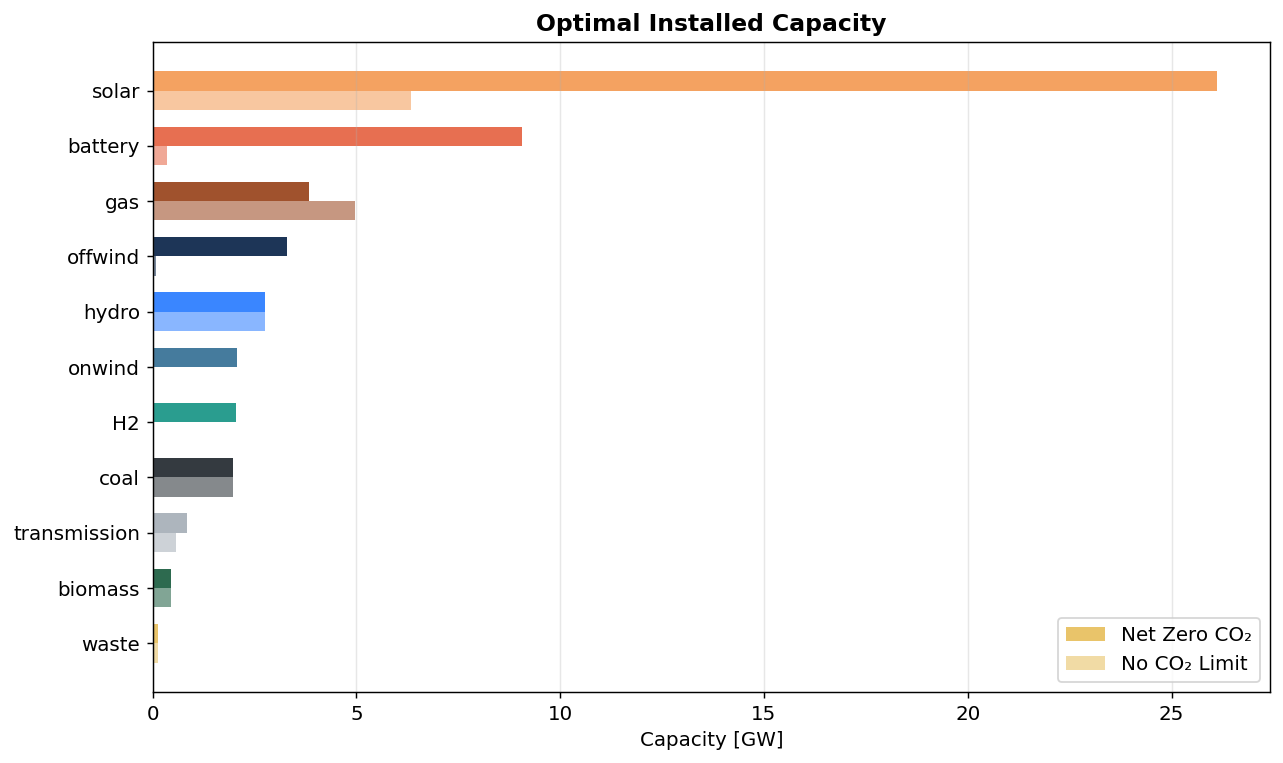

In [16]:
def cap_by_carrier(net):
    gen  = net.generators.groupby('carrier')['p_nom_opt'].sum() / 1e3      # [GW]
    stor = net.storage_units.groupby('carrier')['p_nom_opt'].sum() / 1e3   # [GW]
    tx   = pd.Series({'transmission': net.links['p_nom_opt'].sum() / 1e3}) # [GW]
    return pd.concat([gen, stor, tx])

cap = pd.concat({'No CO₂ Limit':  cap_by_carrier(n_free),
                  'Net Zero CO₂': cap_by_carrier(n_zero)}, axis=1).fillna(0)  # [GW]
cap = cap[cap.sum(axis=1) > 0.01].sort_values('Net Zero CO₂', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(cap)); w = 0.35
colors = [COLORS.get(c, '#adb5bd') for c in cap.index]
ax.barh(x + w/2, cap['Net Zero CO₂'],  w, color=colors,label='Net Zero CO₂')
ax.barh(x - w/2, cap['No CO₂ Limit'],  w, color=colors, alpha=0.6, label='No CO₂ Limit')

ax.set_yticks(x); ax.set_yticklabels(cap.index)
ax.set_xlabel('Capacity [GW]')
ax.set_title('Optimal Installed Capacity', fontsize=13, fontweight='bold')
ax.legend(loc='lower right'); ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig2_capacity.png', dpi=150, bbox_inches='tight')
plt.show()

# from matplotlib.patches import Patch
# 
# fig, ax = plt.subplots(figsize=(10, 6))
# x = np.arange(len(cap)); w = 0.35
# colors = [COLORS.get(c, '#adb5bd') for c in cap.index]
# 
# # Net Zero: kräftig, solide
# ax.barh(x + w/2, cap['Net Zero CO₂'], w,
#         color=colors, edgecolor='black', linewidth=0.6)
# 
# Referenz: blasser + schraffiert
# ax.barh(x - w/2, cap['No CO₂ Limit'], w,
#         color=colors, alpha=0.45, edgecolor='black', linewidth=0.6, hatch='///')
# 
# # Legende manuell -> neutrale Graustufen, keine Carrier-Farbe
# legend_handles = [
#     Patch(facecolor='#4d4d4d', edgecolor='black', label='Net Zero CO₂'),
#     Patch(facecolor='#4d4d4d', edgecolor='black', alpha=0.45, hatch='///',
#           label='No CO₂ Limit'),
# ]
# ax.legend(handles=legend_handles, loc='lower right', frameon=True, framealpha=0.95)
# 
# ax.set_yticks(x); ax.set_yticklabels(cap.index)
# ax.set_xlabel('Capacity [GW]')
# ax.set_title('Optimal Installed Capacity', fontsize=13, fontweight='bold')
# ax.grid(True, axis='x', alpha=0.3)
# ax.set_axisbelow(True)
# plt.tight_layout()
# plt.savefig('fig2_capacity.png', dpi=150, bbox_inches='tight')
# plt.show()

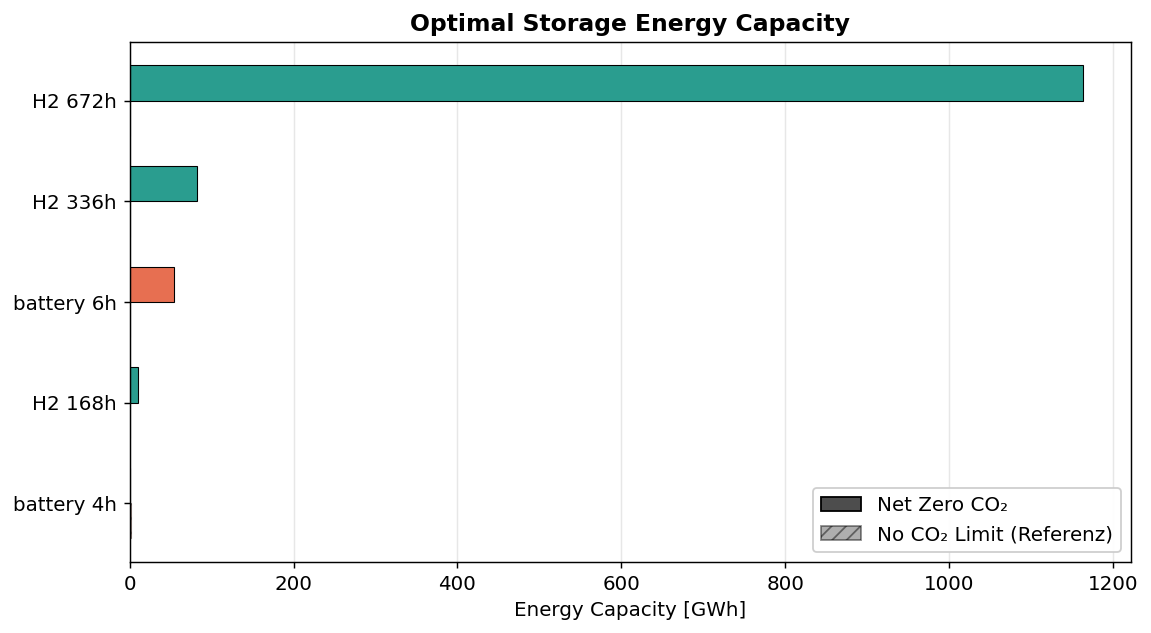

In [17]:
from matplotlib.patches import Patch

def storage_energy(net):
    """Energiekapazität [GWh] je Carrier und Speicherdauer."""
    su = net.storage_units.copy()
    su['e_nom_opt'] = su['p_nom_opt'] * su['max_hours'] / 1e3   # [GWh]
    su['label'] = su['carrier'] + ' ' + su['max_hours'].astype(int).astype(str) + 'h'
    return su.groupby('label')['e_nom_opt'].sum()

e_free = storage_energy(n_free)
e_zero = storage_energy(n_zero)

e = pd.concat({'No CO₂ Limit': e_free, 'Net Zero CO₂': e_zero}, axis=1).fillna(0)
e = e[e.sum(axis=1) > 0.01].sort_values('Net Zero CO₂')

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(e)); w = 0.35
# Farbe nach Basis-Carrier (H2 / battery), nicht nach Label
base = [lbl.split()[0] for lbl in e.index]
colors = [COLORS.get(c, '#adb5bd') for c in base]

ax.barh(x + w/2, e['Net Zero CO₂'], w,
        color=colors, edgecolor='black', linewidth=0.6)
ax.barh(x - w/2, e['No CO₂ Limit'], w,
        color=colors, alpha=0.45, edgecolor='black', linewidth=0.6, hatch='///')

handles = [
    Patch(facecolor='#4d4d4d', edgecolor='black', label='Net Zero CO₂'),
    Patch(facecolor='#4d4d4d', edgecolor='black', alpha=0.45, hatch='///',
          label='No CO₂ Limit (Referenz)'),
]
ax.legend(handles=handles, loc='lower right', framealpha=0.95)
ax.set_yticks(x); ax.set_yticklabels(e.index)
ax.set_xlabel('Energy Capacity [GWh]')
ax.set_title('Optimal Storage Energy Capacity', fontsize=13, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3); ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('fig3_storage_energy.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Fig 2b: Newly built capacity (Net Zero vs No CO₂ limit)

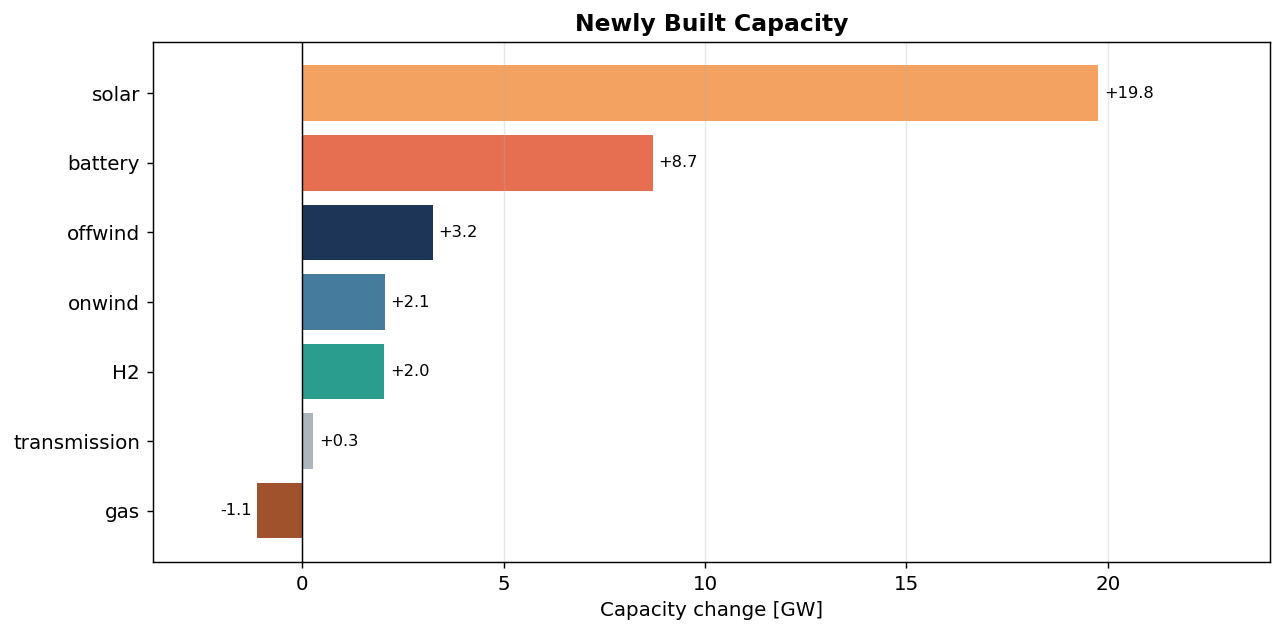

In [18]:
def new_build_by_carrier(net):
    # only extendable components count as "newly built" (p_nom_opt - starting p_nom); fixed existing fleet is excluded
    s = {}
    for _, g in net.generators.iterrows():
        if g.p_nom_extendable:
            s[g.carrier] = s.get(g.carrier, 0) + (g.p_nom_opt - g.p_nom)   # [MW]
    for _, su in net.storage_units.iterrows():
        if su.p_nom_extendable:
            s[su.carrier] = s.get(su.carrier, 0) + (su.p_nom_opt - su.p_nom)  # [MW]
    for _, lk in net.links.iterrows():
        if lk.p_nom_extendable:
            s['transmission'] = s.get('transmission', 0) + (lk.p_nom_opt - lk.p_nom)  # [MW]
    return pd.Series(s) / 1e3   # [GW]

nb_free = new_build_by_carrier(n_free)   # [GW]
nb_zero = new_build_by_carrier(n_zero)   # [GW]
delta = nb_zero.subtract(nb_free, fill_value=0)   # [GW], positive = built more under Net Zero, negative = built less
delta = delta[delta.abs() > 0.01].sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors = [COLORS.get(c, '#adb5bd') for c in delta.index]
bars = ax.barh(delta.index, delta.values, color=colors)
ax.axvline(0, color='k', linewidth=0.8)
ax.bar_label(bars, fmt='%+.1f', padding=3, fontsize=9)
# add horizontal headroom so the outermost bar labels (e.g. +23.4 solar) are not clipped
lo, hi = delta.min(), delta.max()
ax.set_xlim(lo - 0.10 * (hi - lo) - 0.5, hi + 0.18 * (hi - lo) + 0.5)
ax.set_xlabel('Capacity change [GW]')
ax.set_title('Newly Built Capacity', fontsize=13, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('fig2b_newbuild_change.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Fig 3: Electricity mix (annual generation)

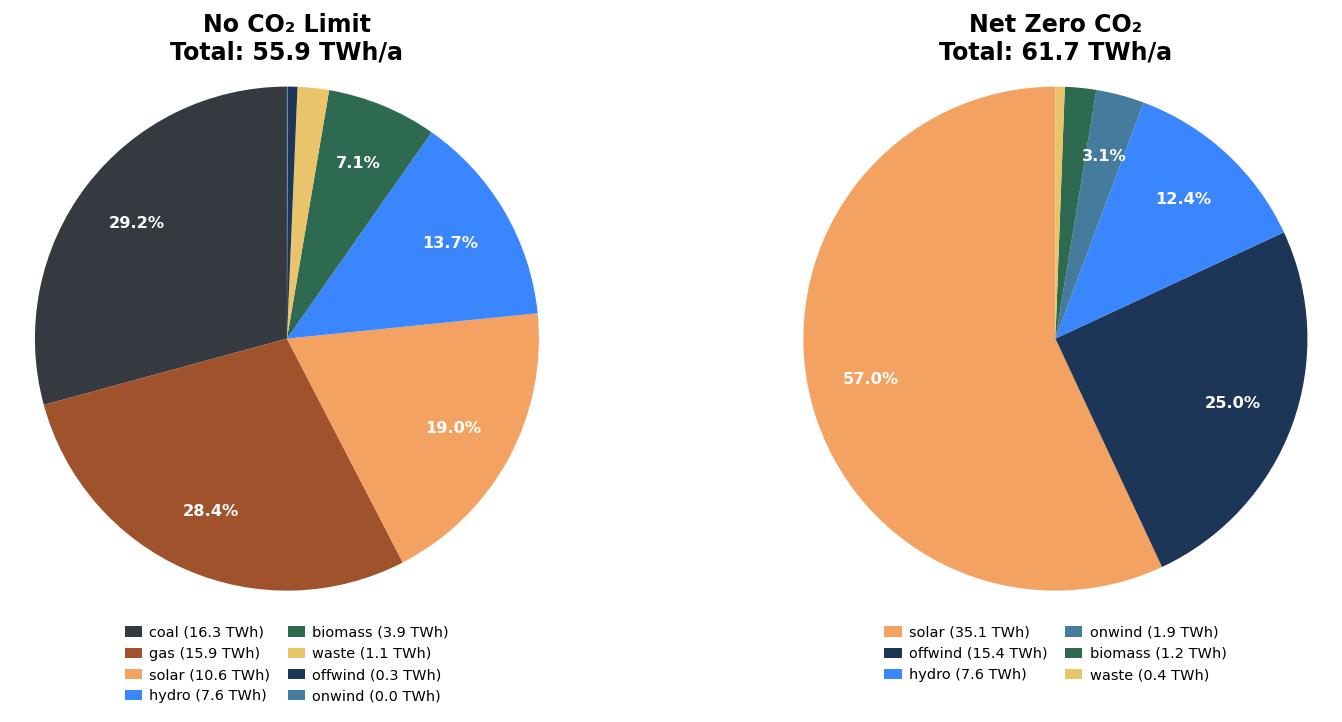

In [19]:
def gen_mix(net):
    """Jahreserzeugung je Carrier [TWh/a]."""
    return (net.generators_t.p
               .multiply(net.snapshot_weightings.generators, axis=0)
               .T.groupby(net.generators.carrier).sum().T
               .sum() / 1e6)

mix = pd.concat({'No CO₂ Limit':  gen_mix(n_free),
                 'Net Zero CO₂': gen_mix(n_zero)}, axis=1).fillna(0)   # [TWh/a]
mix = mix[mix.sum(axis=1) > 0.01]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.6))
for ax, col in [(axes[0], 'No CO₂ Limit'), (axes[1], 'Net Zero CO₂')]:
    data   = mix[col][mix[col] > 0].sort_values(ascending=False)   # [TWh/a]
    colors = [COLORS.get(c, '#adb5bd') for c in data.index]
    wedges, _, autotexts = ax.pie(data.values, colors=colors, radius=1.15,
                          autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
                          startangle=90, pctdistance=0.75,
                          textprops={'color': 'white', 'fontweight': 'bold', 'fontsize': 9})
    ax.legend(wedges, [f'{c} ({v:.1f} TWh)' for c, v in data.items()],
              loc='upper center', bbox_to_anchor=(0.5, 0.0),
              ncol=2, fontsize=8, frameon=False,
              handlelength=1.2, columnspacing=1.2, handletextpad=0.5)
    ax.set_title(f'{col}\nTotal: {data.sum():.1f} TWh/a',
                 fontweight='bold', pad=2)

plt.tight_layout(w_pad=1.0)
plt.savefig('fig3_generation_mix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Fig 4: CO₂ shadow price

CO2 shadow price: 40083.1 EUR/tCO2


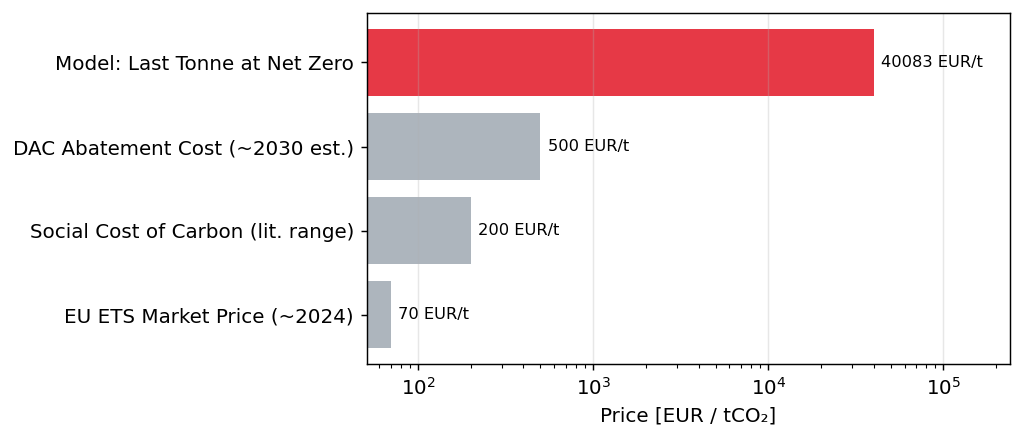

In [20]:
if 'co2_limit' in n_zero.global_constraints.index:
    co2_price = -n_zero.global_constraints.at['co2_limit', 'mu']    # [EUR/t_CO2]
    print(f'CO2 shadow price: {co2_price:.1f} EUR/tCO2')
else:
    co2_price = None
    print('CO2 constraint mu not found.')

if co2_price:
    refs = pd.Series({
        'EU ETS Market Price (~2024)':          70,      # [EUR/t_CO2]
        'Social Cost of Carbon (lit. range)':   200,     # [EUR/t_CO2]
        'DAC Abatement Cost (~2030 est.)':      500,     # [EUR/t_CO2]
        'Model: Last Tonne at Net Zero':        co2_price,
    })
    fig, ax = plt.subplots(figsize=(8, 3.5))
    bars = ax.barh(refs.index, refs.values,
                   color=['#adb5bd', '#adb5bd', '#adb5bd', '#e63946'])
    ax.bar_label(bars, fmt='%.0f EUR/t', padding=4, fontsize=9)
    ax.set_xscale('log')
    ax.set_xlim(right=co2_price * 6)   # headroom so the last bar label is not clipped
    ax.set_xlabel('Price [EUR / tCO₂]')
    #ax.set_title('CO₂ Shadow Price at Net Zero vs. Reference Values', fontweight='bold')
    ax.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('fig4_co2_price.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## Fig 5: Price duration curves

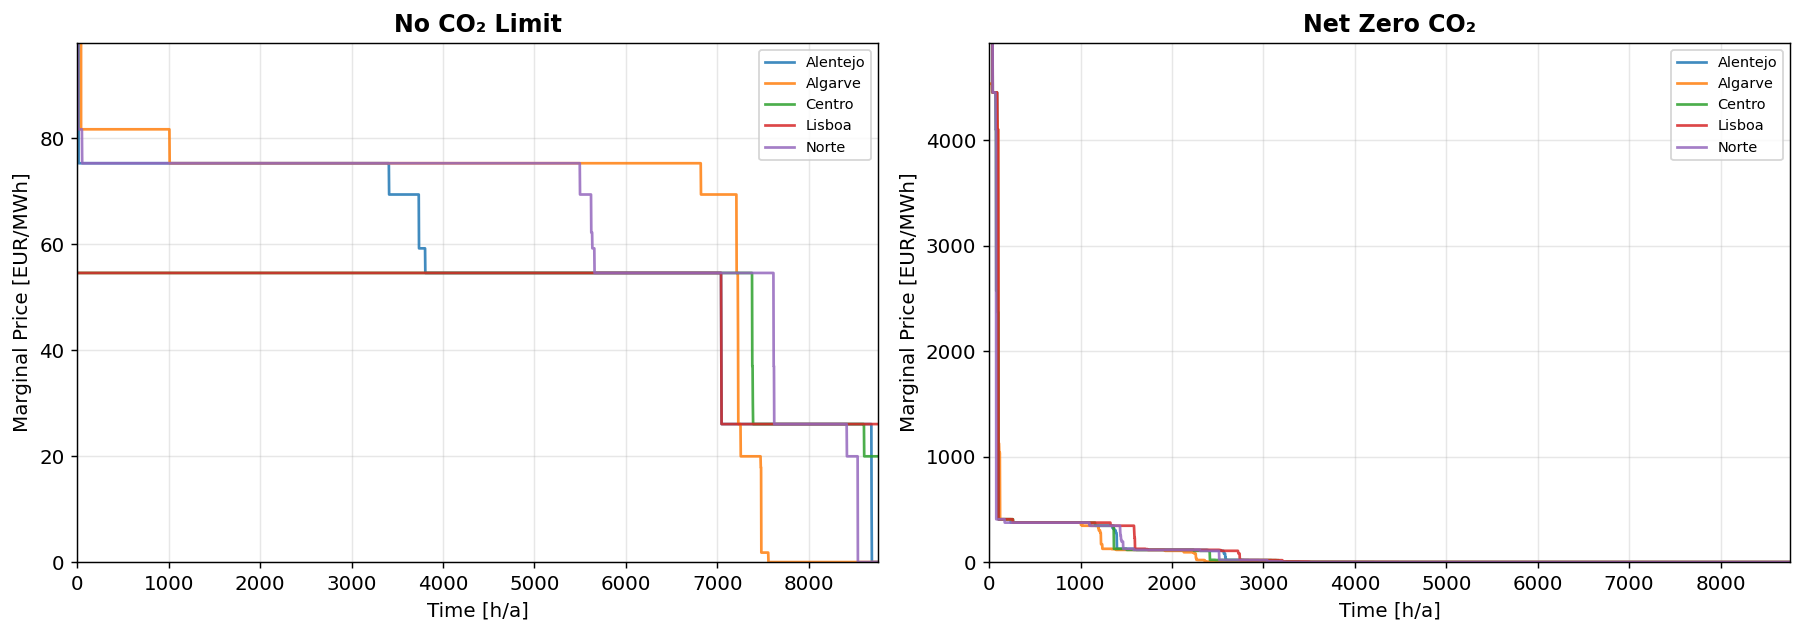

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, net, title in [(axes[0], n_free, 'No CO₂ Limit'), (axes[1], n_zero, 'Net Zero CO₂')]:
    mp = net.buses_t.marginal_price                                  # [EUR/MWh]
    for bus in mp.columns:
        sorted_p = mp[bus].sort_values(ascending=False).values       # [EUR/MWh]
        hours = np.arange(len(sorted_p)) * 3                         # [h]
        ax.plot(hours, sorted_p, label=bus, linewidth=1.5, alpha=0.85)
    y_cap = np.percentile(mp.values, 99) * 1.2                       # [EUR/MWh]
    n_above = int((mp > y_cap).any(axis=1).sum())
    ax.set_ylim(0, y_cap)
    #if n_above > 0:
        #ax.annotate(f'({n_above} scarcity snapshots above {y_cap:.0f} EUR/MWh not shown)',
                    #xy=(0.98, 0.95), xycoords='axes fraction', ha='right', fontsize=7, color='grey')
    ax.set_xlabel('Time [h/a]'); ax.set_ylabel('Marginal Price [EUR/MWh]')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8); ax.set_xlim(0, 8760); ax.grid(True, alpha=0.3)
#plt.suptitle('Price Duration Curve', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_price_duration.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Fig 6: Average electricity prices per region

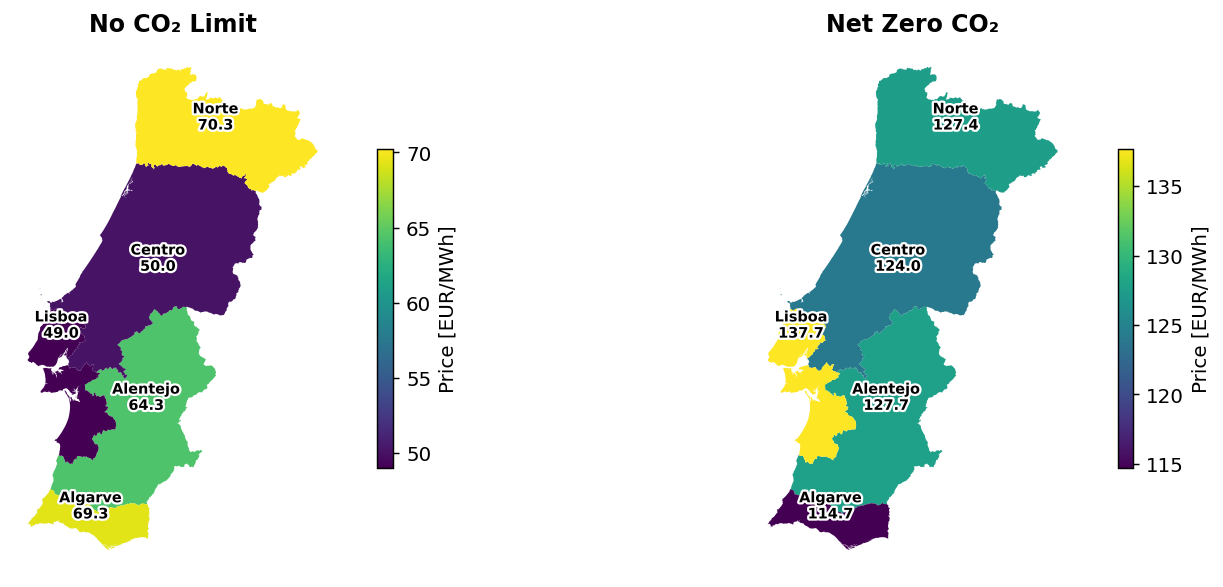

In [22]:
import matplotlib.patheffects as pe

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, net, title in [(axes[0], n_free, 'No CO₂ Limit'), (axes[1], n_zero, 'Net Zero CO₂')]:
    avg = net.buses_t.marginal_price.mean()
    merged = regions.copy(); merged['price'] = avg
    merged.plot(column='price', ax=ax, cmap='viridis', legend=True,
                legend_kwds={'label': 'Price [EUR/MWh]', 'shrink': 0.6})
    for region, row in regions.iterrows():
        pt = row['representative_point']
        ax.annotate(f"{region}\n{avg.get(region, 0):.1f}",
                    (pt.x, pt.y), ha='center', fontsize=8, fontweight='bold',
                    color='black',
                    path_effects=[pe.withStroke(linewidth=2.5, foreground='white')])
    ax.set_title(title, fontweight='bold'); ax.set_axis_off()
plt.tight_layout(rect=[0, 0, 1, 0.93])
# centre the suptitle over the two map axes (the colorbars shift the geometric figure centre)
mid = (axes[0].get_position().x0 + axes[1].get_position().x1) / 2
#fig.suptitle('Avg. Electricity Price per Region', x=mid, y=0.98, fontsize=13, fontweight='bold')
plt.savefig('fig6_avg_prices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Fig 7: Curtailment

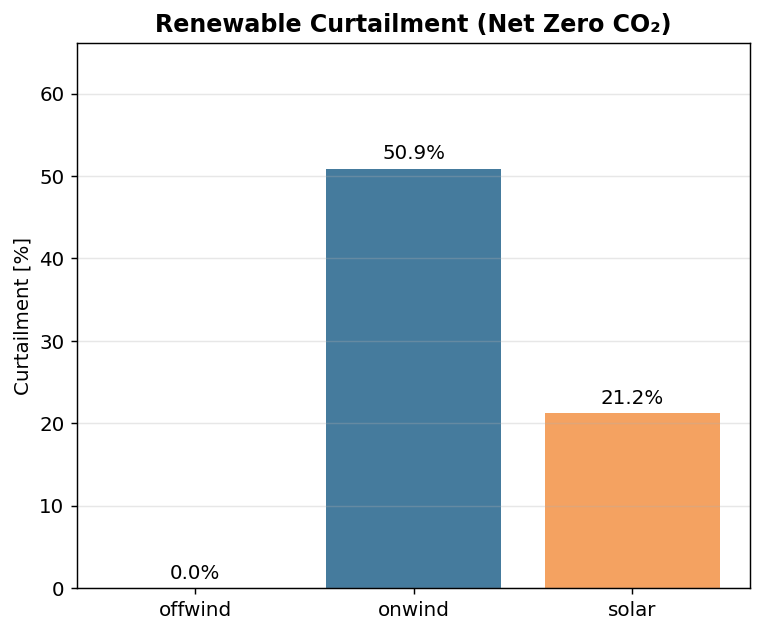

In [23]:
def curtailment(net):
    rows = []
    for name, g in net.generators.iterrows():
        if g.carrier not in ['solar', 'onwind', 'offwind']: continue
        w      = net.snapshot_weightings.generators                 # [h] per snapshot
        avail  = (net.generators_t.p_max_pu[name] * g.p_nom_opt * w).sum()  # [MWh/a] available
        actual = (net.generators_t.p[name] * w).sum()               # [MWh/a] dispatched
        rows.append({'carrier': g.carrier, 'avail': avail, 'curtailed': avail - actual})  # [MWh/a]
    df = pd.DataFrame(rows).groupby('carrier')[['avail','curtailed']].sum()  # [MWh/a]
    df['rate_%'] = (df['curtailed'] / df['avail'].replace(0, np.nan) * 100).fillna(0)  # [%]
    return df

# Only the Net Zero scenario builds renewables; the no-limit run builds none (nothing to curtail).
df = curtailment(n_zero)
fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(df.index, df['rate_%'],
              color=[COLORS.get(c, '#adb5bd') for c in df.index])
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_ylabel('Curtailment [%]')
ax.set_ylim(0, max(df['rate_%'].max() * 1.3, 5))
ax.grid(True, axis='y', alpha=0.3)
ax.set_title('Renewable Curtailment (Net Zero CO₂)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig7_curtailment.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
print(n_free.generators[n_free.generators.p_nom_extendable].groupby('carrier').p_nom_opt.sum())

carrier
gas        1129.175119
offwind      70.362853
onwind       21.050770
solar      6343.966441
Name: p_nom_opt, dtype: float64


---
## Fig 8: Storage filling levels

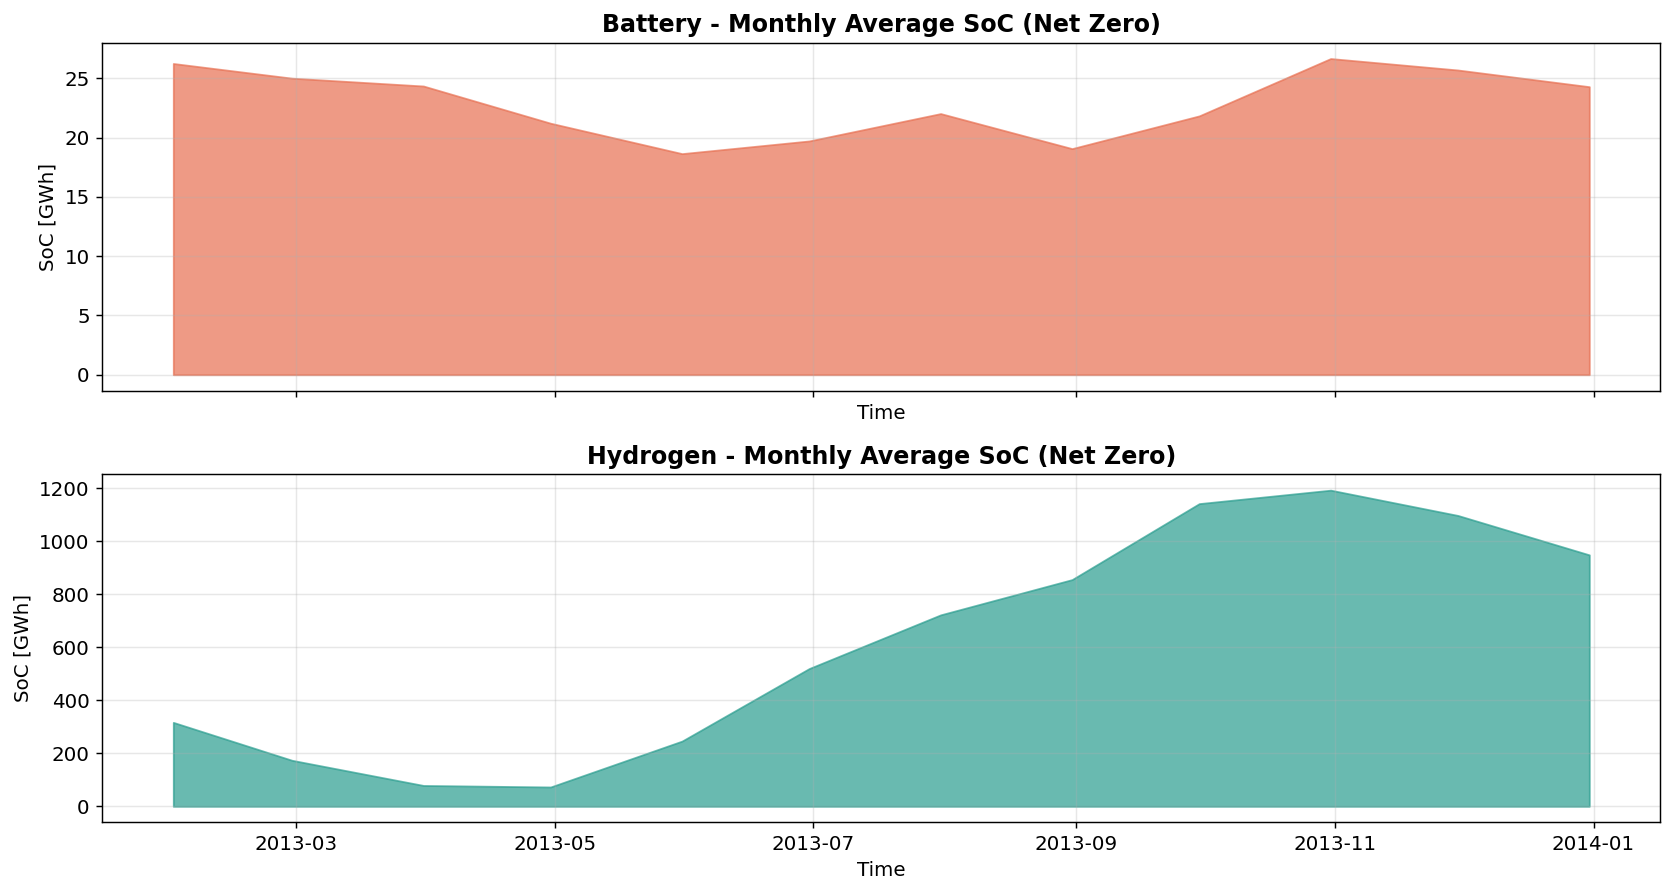

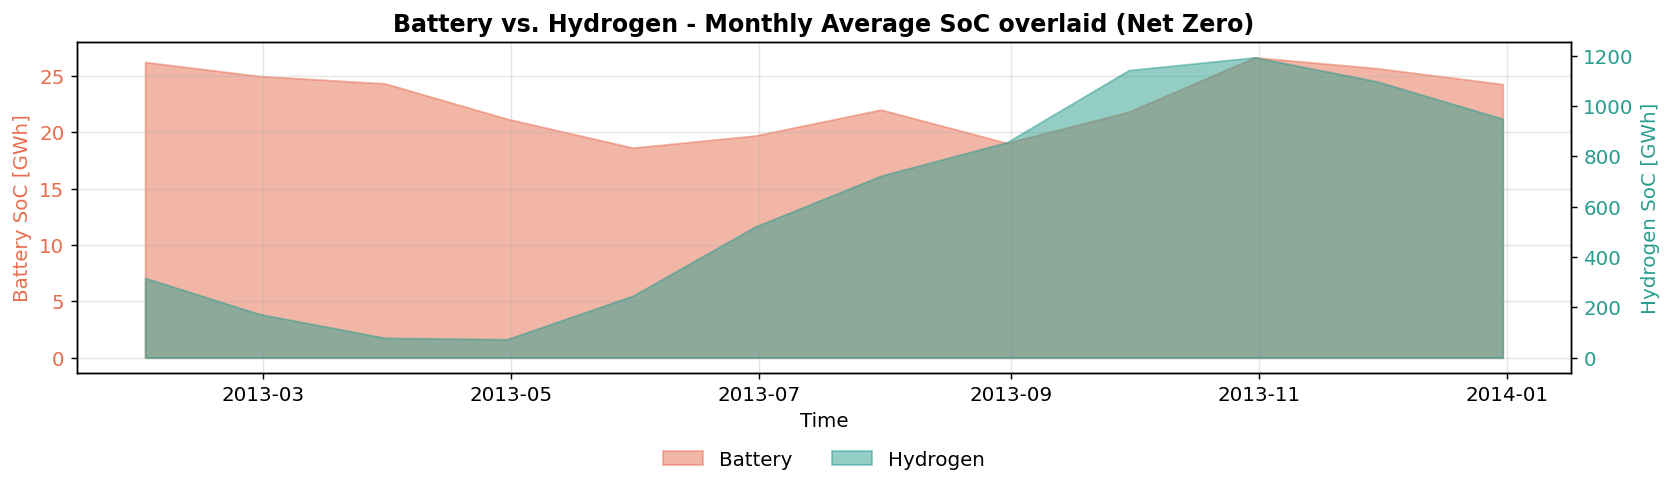

In [25]:
soc = n_zero.storage_units_t.state_of_charge                        # [MWh]
batt_soc = soc[[c for c in soc.columns if 'battery' in c]].sum(axis=1)  # [MWh]
h2_soc   = soc[[c for c in soc.columns if 'H2' in c]].sum(axis=1)   # [MWh]

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax, series, name, color in [
    (axes[0], batt_soc.resample('ME').mean() / 1e3, 'Battery', COLORS['battery']),   # [GWh]
    (axes[1], h2_soc.resample('ME').mean()   / 1e3, 'Hydrogen', COLORS['H2']),        # [GWh]
]:
    ax.fill_between(series.index, series.values, alpha=0.7, color=color)
    ax.set_ylabel('SoC [GWh]'); ax.set_xlabel('Time');ax.grid(True, alpha=0.3)
    ax.set_title(f'{name} - Monthly Average SoC (Net Zero)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig8_storage_levels.png', dpi=150, bbox_inches='tight')
plt.show()

# Overlay: battery (left axis) vs hydrogen (right axis) on one plot

fig, ax1 = plt.subplots(figsize=(13, 4))
b = batt_soc.resample('ME').mean() / 1e3                            # [GWh]
h = h2_soc.resample('ME').mean()   / 1e3                            # [GWh]
ax1.fill_between(b.index, b.values, alpha=0.5, color=COLORS['battery'], label='Battery')
ax1.set_ylabel('Battery SoC [GWh]', color=COLORS['battery'])
ax1.tick_params(axis='y', labelcolor=COLORS['battery'])
ax2 = ax1.twinx()
ax2.fill_between(h.index, h.values, alpha=0.5, color=COLORS['H2'], label='Hydrogen')
ax2.set_ylabel('Hydrogen SoC [GWh]', color=COLORS['H2'])
ax2.tick_params(axis='y', labelcolor=COLORS['H2'])
ax1.set_xlabel('Time')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.5, -0.18),
           ncol=2, frameon=False)

ax1.grid(True, alpha=0.3)
ax1.set_title('Battery vs. Hydrogen - Monthly Average SoC overlaid (Net Zero)', fontweight='bold')
plt.tight_layout()
plt.savefig('fig8b_storage_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Fig 9: System operation (example week)

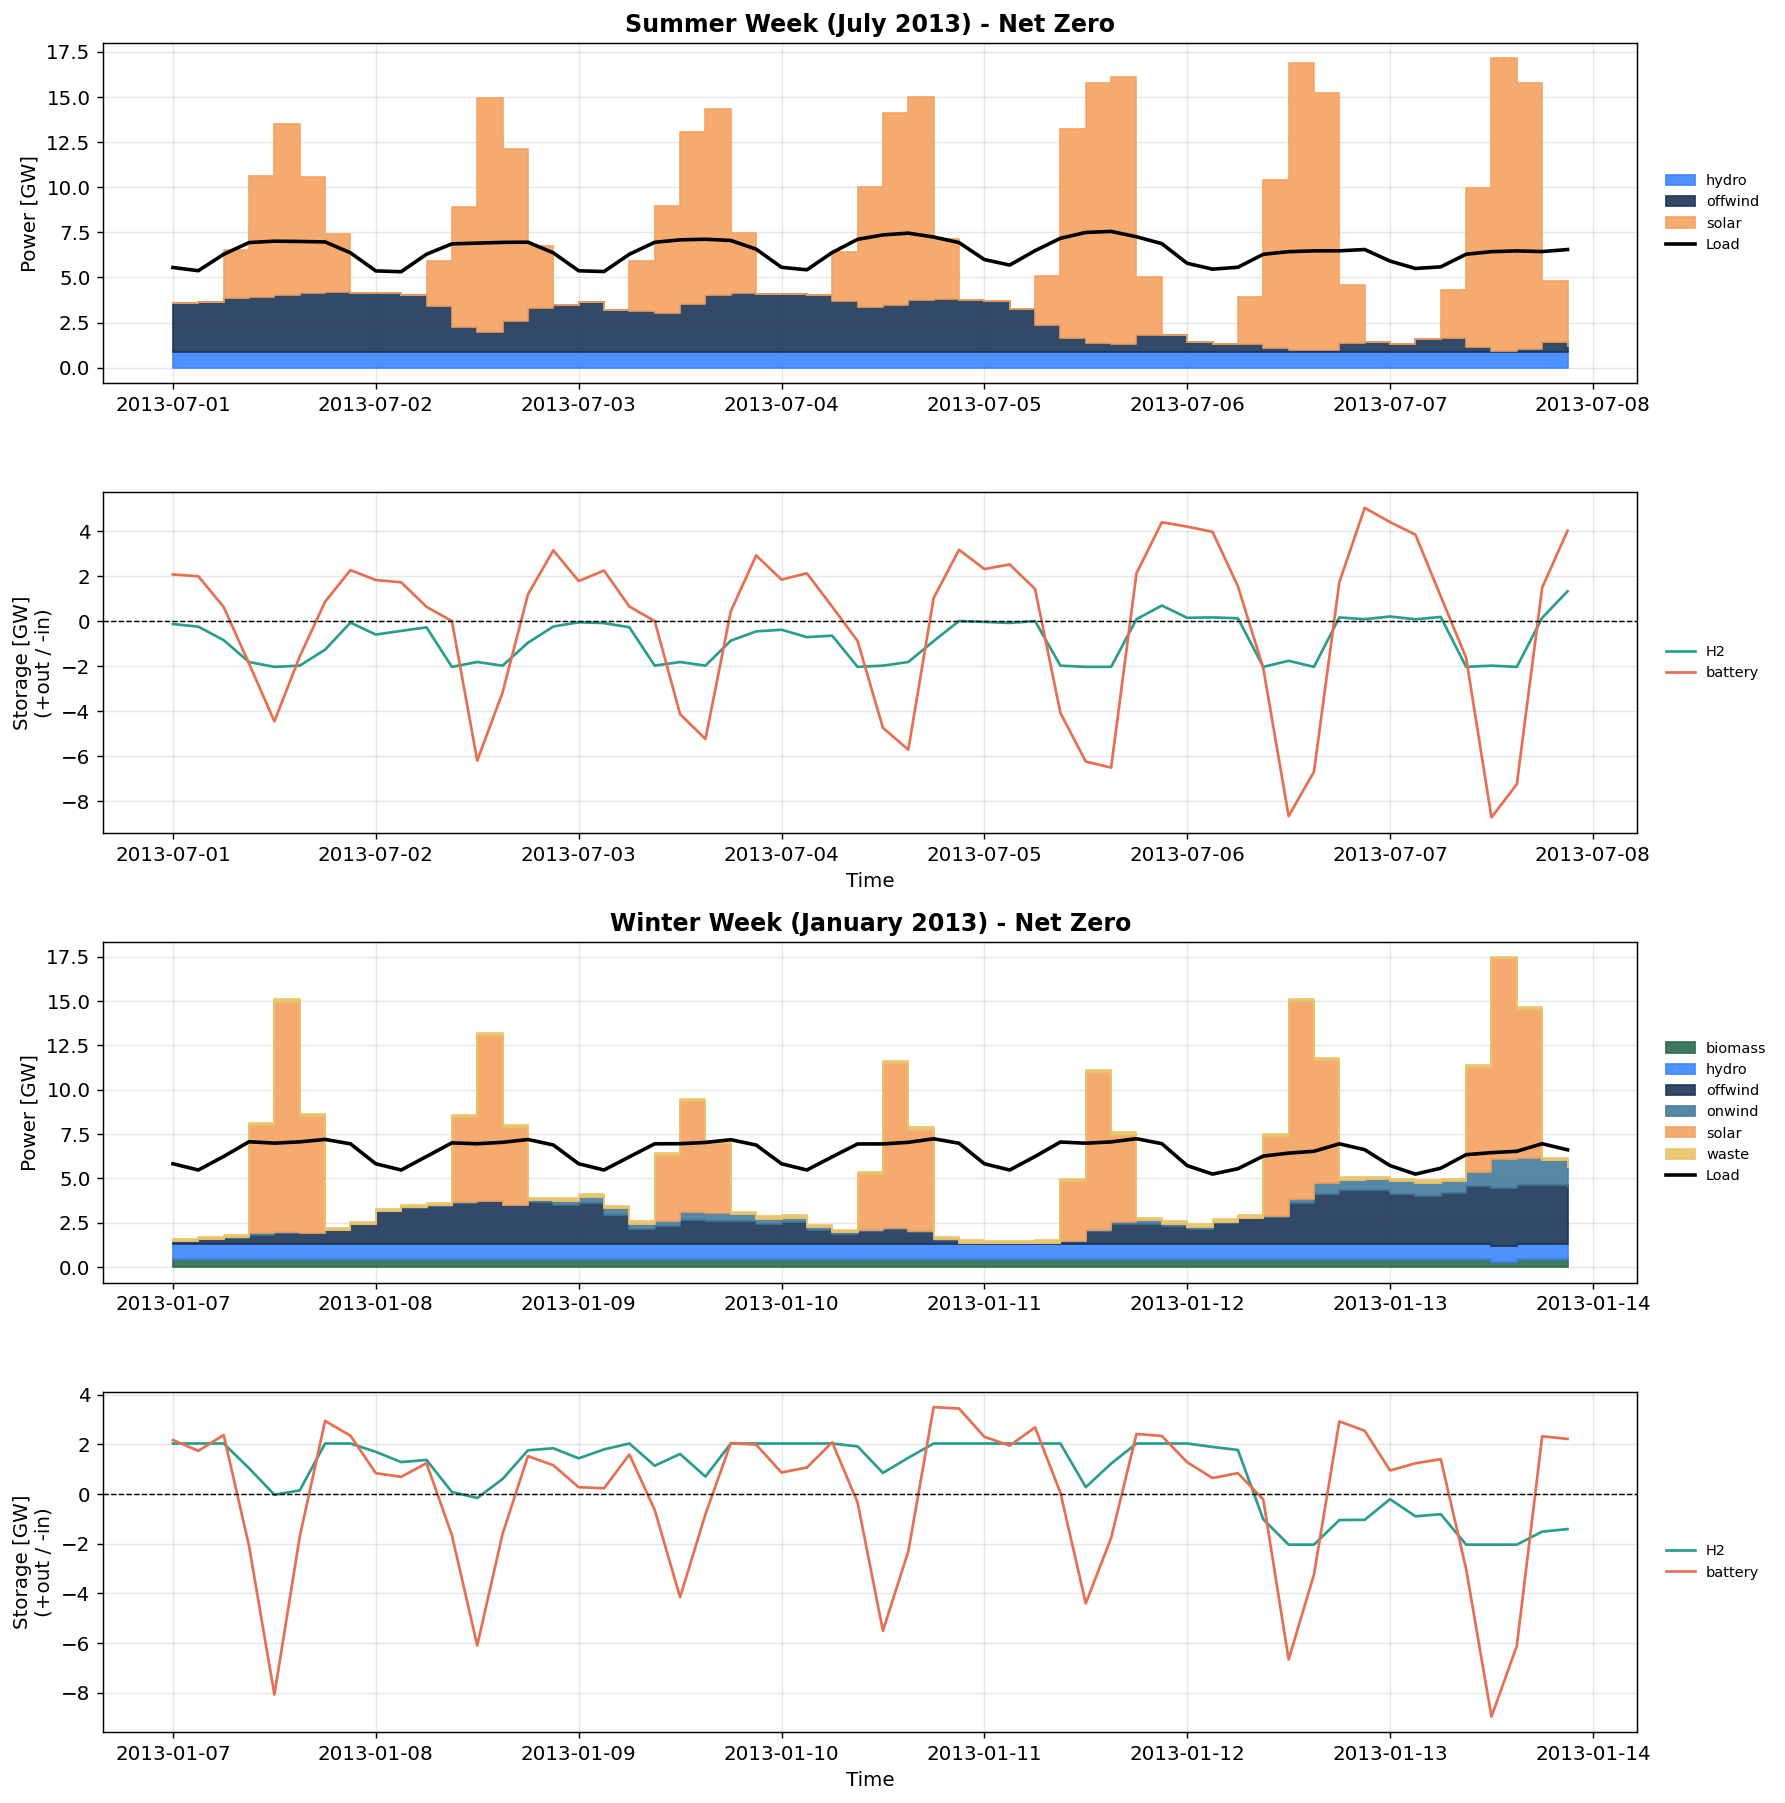

In [26]:
def plot_week(net, start, axes):
    snap = net.snapshots
    week = snap[(snap >= start) & (snap < pd.Timestamp(start) + pd.Timedelta('7D'))]
    gen  = net.generators_t.p.loc[week].T.groupby(net.generators.carrier).sum().T / 1e3        # [GW]
    stor = net.storage_units_t.p.loc[week].T.groupby(net.storage_units.carrier).sum().T / 1e3  # [GW]
    load = net.loads_t.p_set.loc[week].sum(axis=1) / 1e3                                       # [GW]

    ax = axes[0]
    bottom = pd.Series(0., index=week)
    for c in gen.columns:
        if gen[c].abs().max() < 0.01:
            continue
        ax.fill_between(week, bottom, bottom + gen[c], label=c,
                        color=COLORS.get(c, '#adb5bd'), alpha=0.9, step='post')
        bottom += gen[c]
    ax.plot(week, load, color='black', linewidth=2, label='Load', zorder=10)
    ax.set_ylabel('Power [GW]')
    ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=8, frameon=False)
    ax.grid(True, alpha=0.3)
    ax.set_axisbelow(True)

    ax2 = axes[1]
    for c in stor.columns:
        ax2.plot(week, stor[c], label=c, color=COLORS.get(c, '#adb5bd'), linewidth=1.5)
    ax2.axhline(0, color='k', linewidth=0.8, linestyle='--')
    ax2.set_ylabel('Storage [GW]\n(+out / -in)')
    ax2.set_xlabel('Time')
    ax2.legend(loc='center left', bbox_to_anchor=(1.01, 0.5), fontsize=8, frameon=False)
    ax2.grid(True, alpha=0.3)
    ax2.set_axisbelow(True)


fig, axes = plt.subplots(4, 1, figsize=(14, 14))
axes[0].set_title('Summer Week (July 2013) - Net Zero', fontweight='bold')
plot_week(n_zero, '2013-07-01', axes[0:2])
axes[2].set_title('Winter Week (January 2013) - Net Zero', fontweight='bold')
plot_week(n_zero, '2013-01-07', axes[2:4])
plt.tight_layout()
plt.savefig('fig9_dispatch_weeks.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Fig 10: Sensitivity analysis

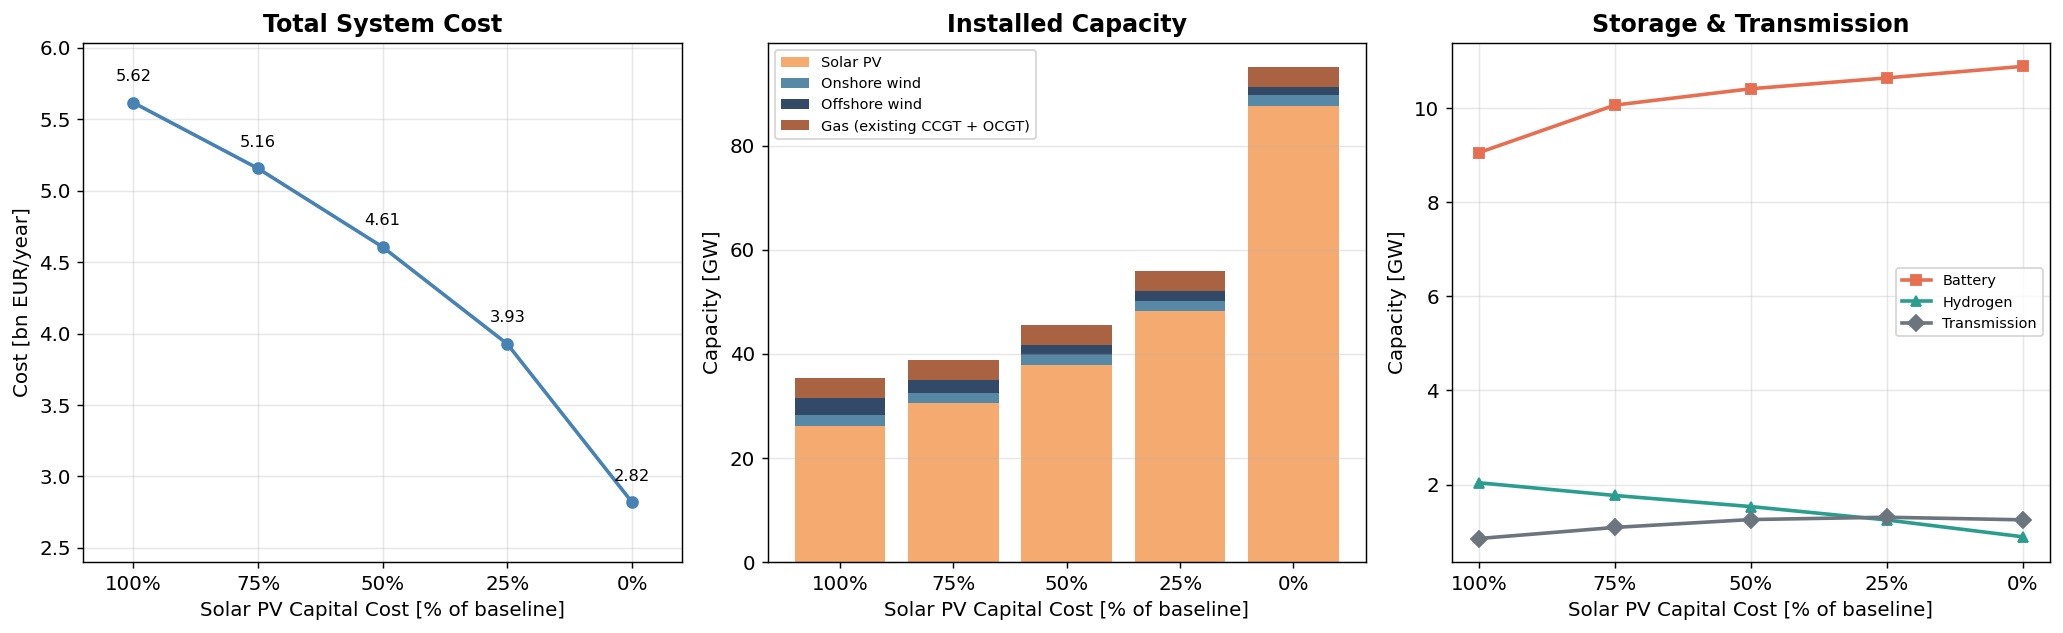

In [27]:

# Cost
x = df_sens.index.tolist()
gas_col = 'gas_GW' if 'gas_GW' in df_sens.columns else 'OCGT_GW'   # backwards compatible
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Cost
axes[0].plot(x, df_sens['total_cost_bn_eur'], marker='o', linewidth=2, color='steelblue')
for xi, yi in zip(x, df_sens['total_cost_bn_eur']):
    axes[0].annotate(f'{yi:.2f}', (xi, yi), xytext=(0, 12), textcoords='offset points',
                     ha='center', fontsize=9)
axes[0].margins(x=0.10, y=0.15)
axes[0].set_title('Total System Cost', fontweight='bold')
axes[0].set_ylabel('Cost [bn EUR/year]'); axes[0].set_xlabel('Solar PV Capital Cost [% of baseline]')
axes[0].grid(True, alpha=0.3)

# Capacity stacked bar
bottom = np.zeros(len(x))
for col, label, color in [
    ('solar_GW',   'Solar PV',      COLORS['solar']),
    ('onwind_GW',  'Onshore wind',  COLORS['onwind']),
    ('offwind_GW', 'Offshore wind', COLORS['offwind']),
    (gas_col,      'Gas (existing CCGT + OCGT)', COLORS['gas']),
]:
    vals = df_sens[col].values                                       # [GW]
    axes[1].bar(x, vals, bottom=bottom, label=label, color=color, alpha=0.9)
    bottom += vals
axes[1].set_title('Installed Capacity', fontweight='bold')
axes[1].set_ylabel('Capacity [GW]'); axes[1].set_xlabel('Solar PV Capital Cost [% of baseline]')
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3, axis='y')

# Storage
axes[2].plot(x, df_sens['battery_GW'], marker='s', label='Battery',   color=COLORS['battery'], linewidth=2)
axes[2].plot(x, df_sens['H2_GW'],      marker='^', label='Hydrogen',  color=COLORS['H2'],      linewidth=2)
axes[2].plot(x, df_sens['transmission_GW'], marker='D', label='Transmission', color=COLORS['AC'], linewidth=2)
axes[2].set_title('Storage & Transmission', fontweight='bold')
axes[2].set_ylabel('Capacity [GW]'); axes[2].set_xlabel('Solar PV Capital Cost [% of baseline]')
axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

#plt.suptitle('Sensitivity analysis: Solar PV Capital Cost (Net Zero CO₂)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig10_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

In [28]:
print(df_sens)
print(len(df_sens))

                total_cost_bn_eur   solar_GW  onwind_GW  offwind_GW  gas_GW  \
solar_cost_pct                                                                
100%                     5.616021  26.112957   2.074086    3.305553   3.829   
75%                      5.155605  30.487714   1.945878    2.528274   3.829   
50%                      4.605447  37.886109   1.894372    1.890915   3.829   
25%                      3.926765  48.258153   1.930631    1.794849   3.829   
0%                       2.819549  87.632978   2.063425    1.460252   3.829   

                battery_GW     H2_GW  transmission_GW  
solar_cost_pct                                         
100%              9.051705  2.037193         0.852668  
75%              10.061717  1.767310         1.088562  
50%              10.409008  1.531433         1.256095  
25%              10.639725  1.247114         1.305012  
0%               10.885048  0.889015         1.250026  
5
